## AGN Homework 7b – Modeling Spectral Energy Distributions

#### Notebook Preamble

In [3]:
%matplotlib inline
%config InlineBackend.figure_formats = ['svg']

import pandas as pd
import numpy as np
import matplotlib as mpl

import matplotlib.pyplot as plt

plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['legend.frameon'] = False
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['axes.formatter.use_mathtext'] = True

from qsosed import SED

### 2. QSOSED

#### Task

#### temp

,source,description,mbh,spin,mdot,dist_mpc,dist_cm
0,SupEddAGN,1) Extreme Narrow Line Seyfert 1,2000000.0,0.90,1.00,180.0,5.554800e+26
1,Ark120,2) Bare Type AGN Seyfert 1,150000000.0,0.83,0.10,140.0,4.320400e+26
2,NGC5548,3) Low Accretion Efficiency Standard Seyfert 1,65000000.0,0.00,0.03,72.0,2.221920e+26



QSOSED Model Initialization...


/home/fritz/.local/miniforge3/envs/7b/lib/python3.10/site-packages/qsosed/sed.py:80: RuntimeWarning: overflow encountered in exp
  planck_spectrum_exp = np.exp(energy / (const.k_B * T))



QSOSED Model Initialization...

QSOSED Model Initialization...
Data successfully calculated and saved to 'super_eddington_sed.csv'.

=== WAVEBAND ENERGY DISTRIBUTION BREAKDOWN ===
 Band Name  Energy Distribution (%)
   Optical                     9.71
        UV                    69.20
Soft X-ray                    11.29
Hard X-ray                     0.02



/tmp/ipykernel_26844/720058517.py:100: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


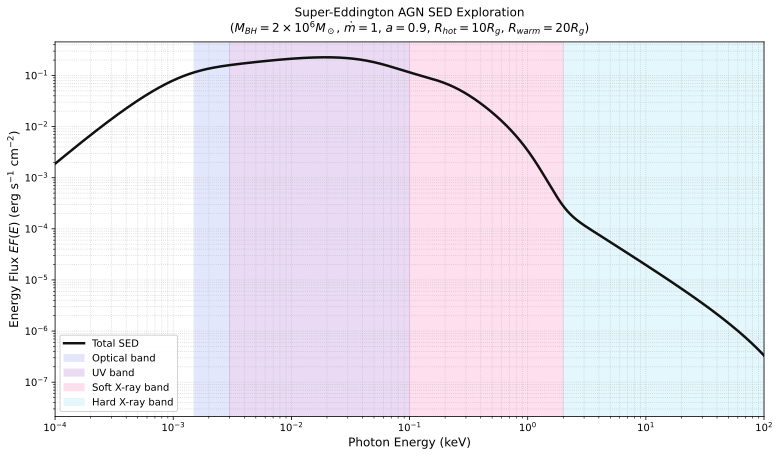

In [17]:
df = pd.DataFrame()

df['source'] = ['SupEddAGN', 'Ark120', 'NGC5548']
df['description'] = ['1) Extreme Narrow Line Seyfert 1',
                     '2) Bare Type AGN Seyfert 1',
                     '3) Low Accretion Efficiency Standard Seyfert 1']
df['mbh'] = [2e6, 1.5e8, 6.5e7]
df['spin'] = [0.9, 0.83, 0.0]
df['mdot'] = [1.0, 0.1, 0.03]
df['dist_mpc'] = [180.0, 140.0, 72.0]
df['dist_cm'] = df['dist_mpc'] * 3.086e24 

display(df)

hotR = 10.0
warmR = 20.0

for key, group in df.groupby(df.columns[0]):
    print('\nQSOSED Model Initialization...')
    model = SED(M = group['mbh'].item(),
                spin = group['spin'].item(),
                mdot = group['mdot'].item())
    model.hot_radius = hotR
    model.warm_radius = warmR


# =============================================================================
# 3. DATA EXTRACTION & PANDAS STORAGE
# =============================================================================
# Extract internal energy grid (keV) and calculate total flux E*F(E)
energy_grid = model.ENERGY_RANGE_KEV
flux_values = model.total_flux(distance_cm)

# Create a clean Pandas DataFrame for easy data manipulation/saving
df = pd.DataFrame({
    'Energy_keV': energy_grid,
    'Flux_EF_E': flux_values
})

# Save raw SED data to CSV for future homework comparisons
#df.to_csv('super_eddington_sed.csv', index=False)
print("Data successfully calculated and saved to 'super_eddington_sed.csv'.")

# =============================================================================
# 4. ENERGY DISTRIBUTION ANALYSIS (Waveband Exploration)
# =============================================================================
# Define standard astronomical wavebands in keV
wavebands = {
    'Optical': (1.5e-3, 3e-3),
    'UV': (3e-3, 0.1),
    'Soft X-ray': (0.1, 2.0),
    'Hard X-ray': (2.0, 100.0)
}

band_fluxes = {}
total_integrated_flux = df['Flux_EF_E'].sum()

# Calculate the energy fraction distributed into each band
for band, (low, high) in wavebands.items():
    mask = (df['Energy_keV'] >= low) & (df['Energy_keV'] <= high)
    band_fluxes[band] = df.loc[mask, 'Flux_EF_E'].sum()

# Display the energy distribution breakdown using a Pandas DataFrame
summary_df = pd.DataFrame({
    'Band Name': band_fluxes.keys(),
    'Integrated Flux Share': band_fluxes.values()
})
summary_df['Energy Distribution (%)'] = (summary_df['Integrated Flux Share'] / total_integrated_flux) * 100

print("\n=== WAVEBAND ENERGY DISTRIBUTION BREAKDOWN ===")
print(summary_df[['Band Name', 'Energy Distribution (%)']].to_string(index=False, float_format="%.2f"))
print("==============================================\n")

# =============================================================================
# 5. VISUALIZATION
# =============================================================================
plt.figure(figsize=(11, 6.5))

# Plot the total spectral energy distribution
plt.loglog(df['Energy_keV'], df['Flux_EF_E'], color='#111111', lw=2.5, label='Total SED')

# Highlight and shade operational bands using the dictionary boundaries
colors = {'Optical': '#4361ee', 'UV': '#7209b7', 'Soft X-ray': '#f72585', 'Hard X-ray': '#4cc9f0'}
for band, (low, high) in wavebands.items():
    plt.axvspan(low, high, color=colors[band], alpha=0.15, label=f'{band} band')

# Plot styling and axis tuning
plt.title(f"Super-Eddington AGN SED Exploration\n"
          f"($M_{{BH}} = 2\\times 10^6 M_\\odot$, $\\dot{{m}}=1$, $a={spin}$, $R_{{hot}}=10R_g$, $R_{{warm}}=20R_g$)", 
          fontsize=12, pad=10)
plt.xlabel("Photon Energy (keV)", fontsize=12)
plt.ylabel("Energy Flux $E F(E)$ ($\mathrm{erg\ s^{-1}\ cm^{-2}}$)", fontsize=12)

plt.xlim(1e-4, 1e2)
# Dynamically scale Y-axis to clip out unphysical zero-flux baselines beautifully
plt.ylim(df.loc[df['Flux_EF_E'] > 0, 'Flux_EF_E'].min() * 0.5, df['Flux_EF_E'].max() * 2)

plt.grid(True, which="both", ls=":", alpha=0.6)
plt.legend(loc='lower left', frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()

# Save the high-resolution plot for your report
#plt.savefig('super_eddington_sed.png', dpi=300)
plt.show()